In [1]:
!pip install opencv-python scikit-learn pandas numpy matplotlib

In [2]:
import cv2
import numpy as np
import pandas as pd
import os
import zipfile
from google.colab import files
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
dataset_zip = "/content/drive/MyDrive/Cancer_Project/dataset.zip"

In [7]:
import zipfile
import os

extract_path = "/content/datasets"

os.makedirs(extract_path, exist_ok=True)

# Extract the single dataset.zip file
with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully to /content/datasets")

Dataset extracted successfully to /content/datasets


In [8]:
import os

for root, dirs, files in os.walk("/content/datasets"):
    print(root, len(files))

/content/datasets 0
/content/datasets/dataset 0
/content/datasets/dataset/blood cancer 0
/content/datasets/dataset/blood cancer/C-NMC_Leukemia 0
/content/datasets/dataset/blood cancer/C-NMC_Leukemia/validation_data 1
/content/datasets/dataset/blood cancer/C-NMC_Leukemia/validation_data/C-NMC_test_prelim_phase_data 1867
/content/datasets/dataset/blood cancer/C-NMC_Leukemia/training_data 0
/content/datasets/dataset/blood cancer/C-NMC_Leukemia/training_data/fold_1 0
/content/datasets/dataset/blood cancer/C-NMC_Leukemia/training_data/fold_1/hem 1163
/content/datasets/dataset/blood cancer/C-NMC_Leukemia/training_data/fold_1/all 2418
/content/datasets/dataset/blood cancer/C-NMC_Leukemia/training_data/fold_0 0
/content/datasets/dataset/blood cancer/C-NMC_Leukemia/training_data/fold_0/hem 1130
/content/datasets/dataset/blood cancer/C-NMC_Leukemia/training_data/fold_0/all 2397
/content/datasets/dataset/blood cancer/C-NMC_Leukemia/training_data/fold_2 0
/content/datasets/dataset/blood cancer/C-N

In [9]:
def extract_features(img_path):

    img = cv2.imread(img_path)

    if img is None:
        return None

    img = cv2.resize(img,(100,100))

    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    gray = gray/255.0

    return gray.flatten()

In [10]:
def train_image_model(dataset_path):

    data=[]
    labels=[]

    folders=os.listdir(dataset_path)

    for label,folder in enumerate(folders):

        folder_path=os.path.join(dataset_path,folder)

        if os.path.isdir(folder_path):

            for img in os.listdir(folder_path):

                img_path=os.path.join(folder_path,img)

                features=extract_features(img_path)

                if features is not None:

                    data.append(features)
                    labels.append(label)

    X=np.array(data)
    y=np.array(labels)

    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

    model=RandomForestClassifier()

    model.fit(X_train,y_train)

    acc=accuracy_score(y_test,model.predict(X_test))

    print("Model Accuracy:",acc)

    return model

Overall Model Accuracy: 0.7761


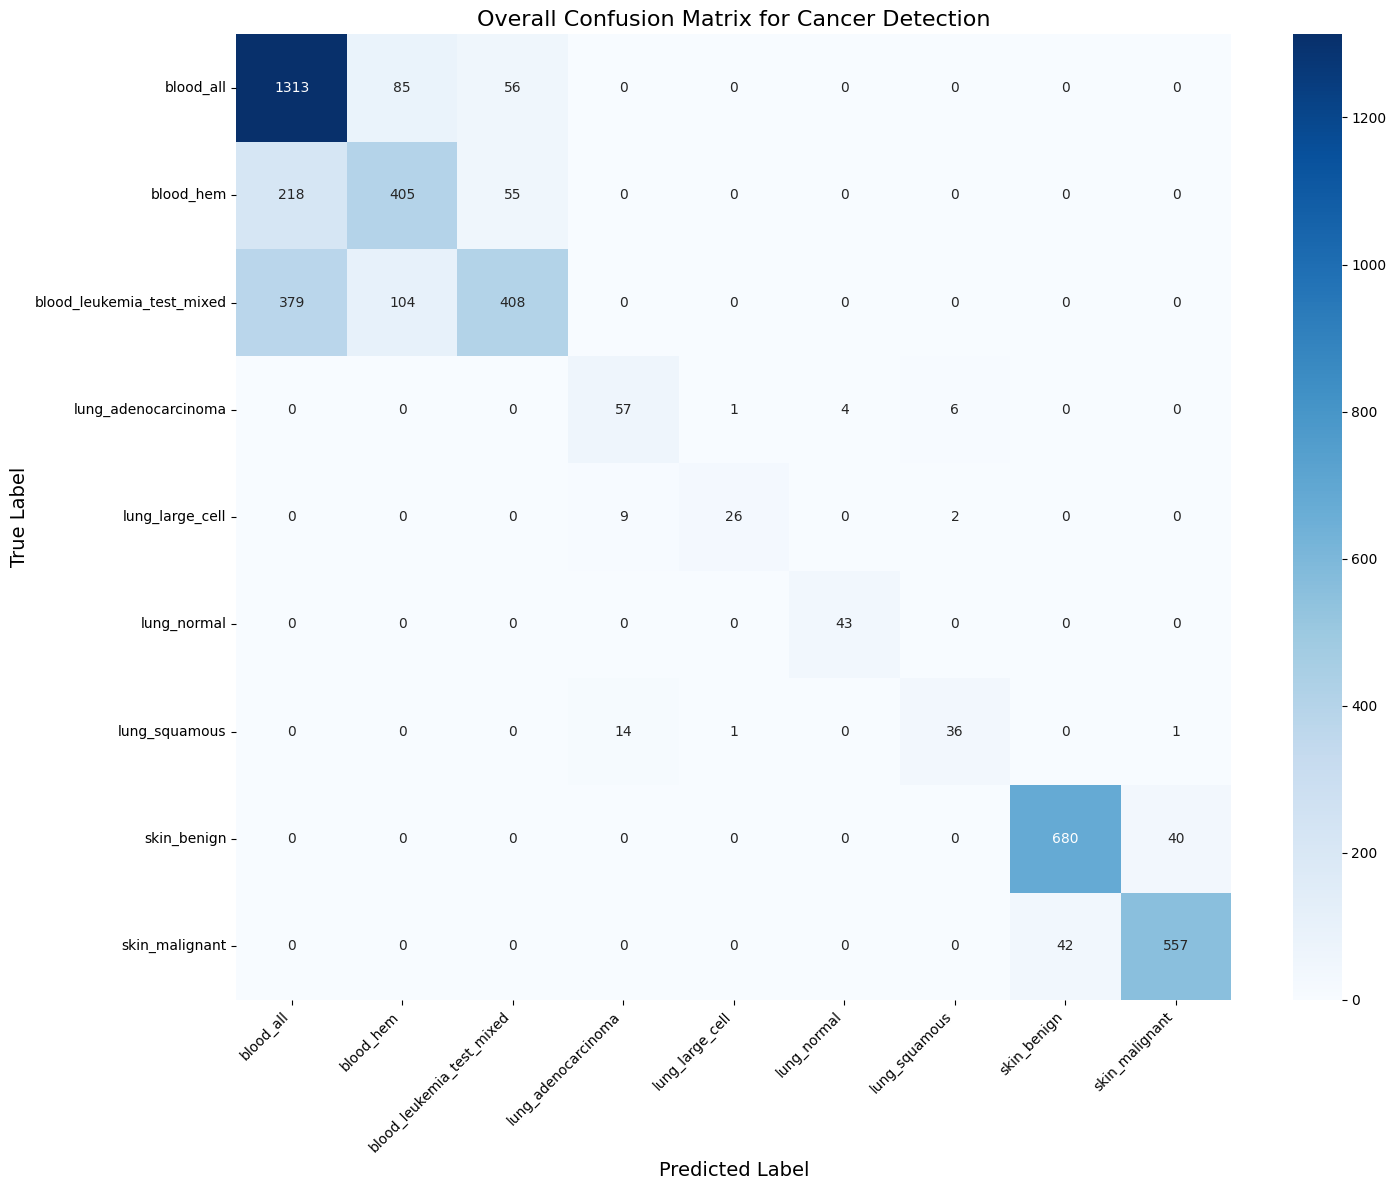

In [11]:
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

base_dataset_path = "/content/datasets/dataset"
all_features, all_labels_str = [], []

def load_data_for_cancer_type(root_dir, cancer_prefix):
    data, labels_str = [], []
    for root, dirs, files in os.walk(root_dir):
        if not files: continue
        cf = os.path.basename(root) # Current folder name
        gf = os.path.basename(os.path.dirname(root)) # Grandparent folder name

        label = None
        if cancer_prefix == 'blood':
            if cf == 'hem': label = 'blood_hem'
            elif cf == 'all': label = 'blood_all'
            elif gf in ['validation_data', 'testing_data']: label = 'blood_leukemia_test_mixed'
        elif cancer_prefix == 'skin' and cf in ['malignant', 'benign']:
            label = f"{cancer_prefix}_{cf}"
        elif cancer_prefix == 'lung':
            if 'squamous' in cf: label = 'lung_squamous'
            elif 'large.cell' in cf: label = 'lung_large_cell'
            elif 'adenocarcinoma' in cf: label = 'lung_adenocarcinoma'
            elif 'normal' in cf: label = 'lung_normal'

        if label:
            for fn in files:
                f = extract_features(os.path.join(root, fn))
                if f is not None: data.append(f); labels_str.append(label)
    return np.array(data), labels_str

blood_root = os.path.join(base_dataset_path, "blood cancer", "C-NMC_Leukemia")
X_blood, y_blood_str = load_data_for_cancer_type(blood_root, "blood")
all_features.extend(X_blood); all_labels_str.extend(y_blood_str)

skin_root = os.path.join(base_dataset_path, "skin cancer")
X_skin, y_skin_str = load_data_for_cancer_type(skin_root, "skin")
all_features.extend(X_skin); all_labels_str.extend(y_skin_str)

lung_root = os.path.join(base_dataset_path, "lung cancer", "Data")
X_lung, y_lung_str = load_data_for_cancer_type(lung_root, "lung")
all_features.extend(X_lung); all_labels_str.extend(y_lung_str)

X_combined = np.array(all_features)
y_combined_str = np.array(all_labels_str)

le = LabelEncoder()
y_combined = le.fit_transform(y_combined_str)
class_names = le.classes_

if len(X_combined) > 0:
    X_train, X_test, y_train, y_test = train_test_split(X_combined, y_combined, test_size=0.2, random_state=42, stratify=y_combined)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"Overall Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(15, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.title('Overall Confusion Matrix for Cancer Detection', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [14]:
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Model Accuracy: 77.61%


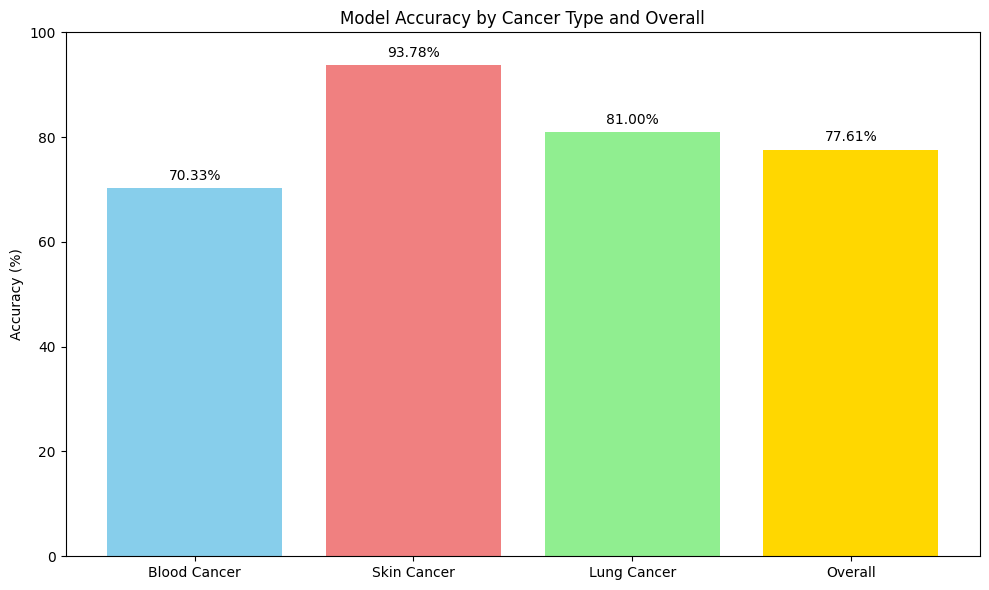

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

y_test_str = le.inverse_transform(y_test)
y_pred_str = le.inverse_transform(y_pred)

def get_accuracy(true_labels, pred_labels, prefixes):
    mask = np.array([any(label.startswith(p) for p in prefixes) for label in true_labels])
    if not np.any(mask): return 0
    return accuracy_score(true_labels[mask], pred_labels[mask])

accuracies = {
    'Blood Cancer': get_accuracy(y_test_str, y_pred_str, ['blood_']),
    'Skin Cancer': get_accuracy(y_test_str, y_pred_str, ['skin_']),
    'Lung Cancer': get_accuracy(y_test_str, y_pred_str, ['lung_']),
    'Overall': accuracy_score(y_test, y_pred)
}

labels, values = list(accuracies.keys()), list(accuracies.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, [v * 100 for v in values], color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.ylabel('Accuracy (%)'); plt.title('Model Accuracy by Cancer Type and Overall'); plt.ylim(0, 100)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height():.2f}%', ha='center', va='bottom')
plt.tight_layout(); plt.show()

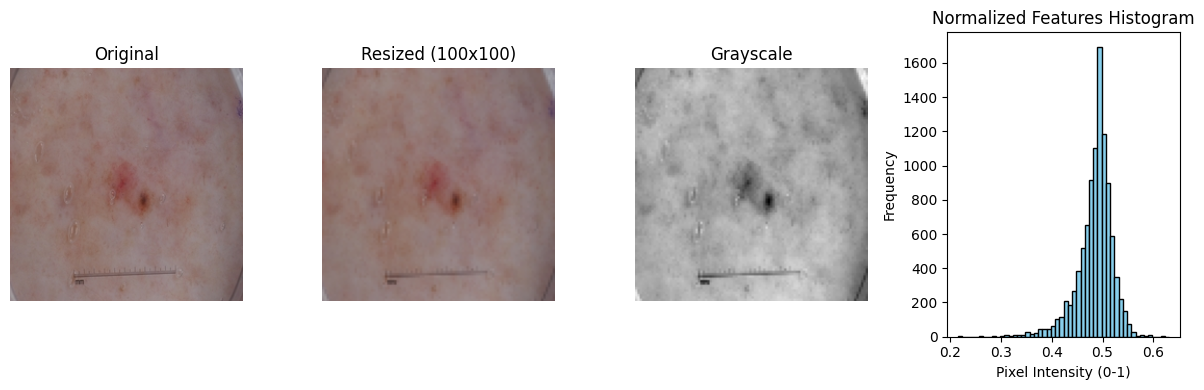

In [17]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

# Find an example image path (assuming a dataset image exists)
example_img_path = None
for root, _, files in os.walk('/content/datasets'):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            example_img_path = os.path.join(root, f)
            break
    if example_img_path: break

if example_img_path:
    img_orig = cv2.imread(example_img_path)
    if img_orig is None:
        print(f"Error: Could not load image from {example_img_path}")
    else:
        # Convert BGR to RGB for matplotlib display for original image
        img_orig_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

        # Resize
        img_resized = cv2.resize(img_orig, (100, 100))
        img_resized_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

        # Grayscale
        img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

        # Normalize (feature vector)
        features_normalized = img_gray / 255.0
        features_flattened = features_normalized.flatten()

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 4, 1)
        plt.imshow(img_orig_rgb)
        plt.title('Original')
        plt.axis('off')

        plt.subplot(1, 4, 2)
        plt.imshow(img_resized_rgb)
        plt.title('Resized (100x100)')
        plt.axis('off')

        plt.subplot(1, 4, 3)
        plt.imshow(img_gray, cmap='gray')
        plt.title('Grayscale')
        plt.axis('off')

        plt.subplot(1, 4, 4)
        plt.hist(features_flattened, bins=50, color='skyblue', edgecolor='black')
        plt.title('Normalized Features Histogram')
        plt.xlabel('Pixel Intensity (0-1)')
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()
else:
    print("No image found in the dataset to visualize feature extraction.")

In [19]:
from google.colab import files

# Assuming the model is saved as 'cancer_detection_model.joblib'
files.download('cancer_detection_model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import joblib

# Save the trained model to a file
model_filename = 'cancer_detection_model.joblib'
joblib.dump(model, model_filename)

# Save the LabelEncoder to a file
le_filename = 'label_encoder.joblib'
joblib.dump(le, le_filename)

print(f"Model successfully saved to {model_filename}")
print(f"LabelEncoder successfully saved to {le_filename}")

Model successfully saved to cancer_detection_model.joblib
LabelEncoder successfully saved to label_encoder.joblib


In [22]:
from google.colab import files

# Download the saved model and label encoder
files.download('cancer_detection_model.joblib')
files.download('label_encoder.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import joblib

# Save the trained model to a file
model_filename = 'cancer_detection_model.joblib'
joblib.dump(model, model_filename)

print(f"Model successfully saved to {model_filename}")

Model successfully saved to cancer_detection_model.joblib
